### Tecnologie dei dati e del linguaggio
# Dati e informazione
## Prof. Alfio Ferrara

## Informazione e incertezza
L'informazione è qualcosa che cambia il nostro sapere sul mondo e un modo per misurare questo effetto è osservare quanto un **dato**, ovvero un elemento di potenziale conoscenza, un'osservazione sulla realtà, possa ridurre il nostro grado di incertezza circa un evento, un fenomeno e più in generale sulla realtà che osserviamo.

### Esempio: indovina la città
Le città possibili sono: "New York", "Tokyo", "Parigi", "Londra", "Sydney", "Milano", "Città del Capo", "Mosca", "Roma", "Pechino"

Senza sapere nulla né fare domande, qual è la probabilità di indovinare?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
p = 1 / 2
-np.log2(p)

In [ ]:
p1, p2, p3 = 0.9, 0.05, 0.05
H = p1*-np.log2(p1) + p2*-np.log2(p2) + p3*-np.log2(p3)
H 

In [ ]:
citta = ["New York", "Tokyo", "Parigi", "Londra", "Sydney", "Milano", "Città del Capo", "Mosca", "Roma", "Pechino"]
p = np.array([1 / len(citta) for x in citta])

fig, ax = plt.subplots(figsize=(12, 2))
sns.barplot(x=citta, y=p, ax=ax)
ax.set_ylim((0, 1))
plt.tight_layout()
plt.show()

Quanta incertezza abbiamo? Un modo per misurarlo è usare l'**entropia** come misura della quantità di informazione contenuta in un messaggio. Al momento non abbiamo alcun messaggio circa la città giusta, perciò ci troviamo in una situazione la cui incertezza può essere misurata osservando la distribuzione di probabilità circa gli esiti possibili, con questa formula (**entropia**):

$$
H = - \sum\limits_{i=0}^{n} p_i \log_2 p_i
$$

In [ ]:
def entropia(probs):
    return -sum(p * np.log2(p) for p in probs if p > 0)

print(f"Nessun messaggio: {np.round(entropia(p), 2)} bit")

### L'effetto dei dati
Immaginiamo di fare ora una domanda e grazie a essa scoprire che la città da indovinare è in Europa. Come cambia ciò che sappiamo?

In [ ]:
citta_eu = ['Parigi', 'Londra', 'Milano', 'Roma']
p_eu = np.array([1 / len(citta_eu) if c in citta_eu else 0 for c in citta])

fig, ax = plt.subplots(figsize=(12, 2))
sns.barplot(x=citta, y=p_eu, ax=ax)
ax.set_ylim((0, 1))
plt.tight_layout()
plt.show()

In [ ]:
entropia_none = entropia(p)
entropia_eu = entropia(p_eu)
print(f"Nessun messaggio: {np.round(entropia_none, 2)} bit")
print(f"Città EU: {np.round(entropia_eu, 2)} bit")
print(f"Riduzione di incertezza: {np.round(entropia_none - entropia_eu, 2)} bit")

Ora, immaginiamo invece di scoprire con una domanda che la città è in Italia

In [ ]:
citta_it = ['Milano', 'Roma']
p_it = np.array([1 / len(citta_it) if c in citta_it else 0 for c in citta])

fig, ax = plt.subplots(figsize=(12, 2))
sns.barplot(x=citta, y=p_it, ax=ax)
ax.set_ylim((0, 1))
plt.tight_layout()
plt.show()

In [ ]:
entropia_none = entropia(p)
entropia_it = entropia(p_it)
print(f"Nessun messaggio: {np.round(entropia_none, 2)} bit")
print(f"Città IT: {np.round(entropia_it, 2)} bit")
print(f"Riduzione di incertezza: {np.round(entropia_none - entropia_it, 2)} bit")

#### Quale dei due dati è stato più informativo?

Si noti che se dovessimo scegliere quale domanda fare la questione sarebbe diversa, perchè dobbiamo anche considerare il caso in cui la risposta sia "no" e pertanto non si riduca affatto la nostra incertezza, anzi, al contrario se la città non fosse italiana e l'incertezza sarebbe maggiore rispetto al caso in cui la città non è europea.

Dunque non fare alcuna domanda ha valore:

In [ ]:
print(f"Nessuna domanda: {np.round(-1/10 * np.log2(1/10), 2)}")

Ma chiedere: *"E' una città italiana?"* significa avere $\frac{1}{2}$ di probabilità nel caso di risposta affermativa, ma $\frac{1}{8}$ nel caso di risposta negativa. Se invece chiediamo *"E' una città europea?"*, abbiamo $\frac{1}{4}$ in caso affermativo e $\frac{1}{6}$ in caso negativo. Pertanto:

In [ ]:
print(f"Città italiana?: {np.round(entropia(np.array([1/2, 1/8])), 2)}")
print(f"Città europea?: {np.round(entropia(np.array([1/4, 1/6])), 2)}")

## Dati e contesto interpretativo
Un'altro modo di rendere dei dati informativi è fornire loro un contesto interpretativo. Assumiamo di ricevere dei dati che ne siano privi, come ad esempio questi:

In [15]:
R = pd.read_csv('data/data-rec.csv', index_col=0, header=None, skiprows=1)
data = [int(x) for x in R[2].values]
print(data)

[100, 150, 10, 5, 150, 50, 10, 5, 2, 30, 5, 100, 50, 30, 10, 100, 200, 10]


Una prima forma di contesto consiste nell'aggiungere una relazione ai dati esistenti

In [16]:
tuple = list(zip(data, R[3].values))
for record in tuple:
    print(record)

(100, 'g')
(150, 'g')
(10, 'ml')
(5, 'g')
(150, 'g')
(50, 'g')
(10, 'ml')
(5, 'ml')
(2, 'pezzi')
(30, 'g')
(5, 'g')
(100, 'g')
(50, 'g')
(30, 'g')
(10, 'ml')
(100, 'g')
(200, 'ml')
(10, 'g')


In [17]:
R

,1,2,3,4,5,6,7
0,,,,,,,
0,Pasta,100,g,1.5,75.0,12.0,Pasta al Pomodoro
1,Pomodori pelati,150,g,0.2,8.0,1.2,Pasta al Pomodoro
2,Olio d'oliva,10,ml,9.0,0.0,0.0,Pasta al Pomodoro
3,Aglio,5,g,0.0,1.0,0.2,Pasta al Pomodoro
4,Petto di pollo,150,g,3.0,0.0,31.0,Insalata di Pollo
5,Insalata mista,50,g,0.2,3.0,1.0,Insalata di Pollo
6,Olio d'oliva,10,ml,9.0,0.0,0.0,Insalata di Pollo
7,Succo di limone,5,ml,0.0,1.2,0.0,Insalata di Pollo
8,Uova,2,pezzi,10.0,1.1,12.0,Omelette al Formaggio


In [18]:
R = pd.read_csv('data/data-rec.csv', index_col=0)
R 

,nome,quantità,unità,grassi,carboidrati,proteine,ricetta
0,Pasta,100,g,1.5,75.0,12.0,Pasta al Pomodoro
1,Pomodori pelati,150,g,0.2,8.0,1.2,Pasta al Pomodoro
2,Olio d'oliva,10,ml,9.0,0.0,0.0,Pasta al Pomodoro
3,Aglio,5,g,0.0,1.0,0.2,Pasta al Pomodoro
4,Petto di pollo,150,g,3.0,0.0,31.0,Insalata di Pollo
5,Insalata mista,50,g,0.2,3.0,1.0,Insalata di Pollo
6,Olio d'oliva,10,ml,9.0,0.0,0.0,Insalata di Pollo
7,Succo di limone,5,ml,0.0,1.2,0.0,Insalata di Pollo
8,Uova,2,pezzi,10.0,1.1,12.0,Omelette al Formaggio
9,Formaggio,30,g,9.0,1.0,7.0,Omelette al Formaggio


## Immagini

In [19]:
from utils.visual import process_image

In [24]:
sample = np.random.randint(0, 255, size=(12, 12))
sample

array([[100, 160,  43, 218, 197, 231,   6, 159,  80, 194,  65, 228],
       [239, 170,  89, 108, 141,  45, 206,  30, 115, 118,  18, 185],
       [208, 254, 185, 110, 228,  55, 157,  42,  79, 222, 210,  97],
       [ 19,  87,  24, 181, 108,  77, 127, 171,  31,  76, 248,  15],
       [ 30,  52,  74,  11, 200, 223, 228,  93, 156, 109, 161, 191],
       [ 65, 154, 123, 115, 145, 191, 156, 108,  57, 221, 157, 145],
       [ 61,  50, 148, 143,   6,  21, 117, 179, 206, 193, 106,  83],
       [ 33,  73, 100,  99,  41,  31, 232, 248, 193, 251, 184, 205],
       [ 45, 125,  46,  20,  92, 201, 247, 221,  46,  18, 100, 170],
       [141, 201, 176,  81, 123, 176, 121, 194,  70, 236, 179,  88],
       [130, 165,  94, 137,  65, 117, 116, 194,  43, 135,  33, 217],
       [171,   2,   1,  60, 139, 226, 182, 153, 234, 203,  57,  26]])

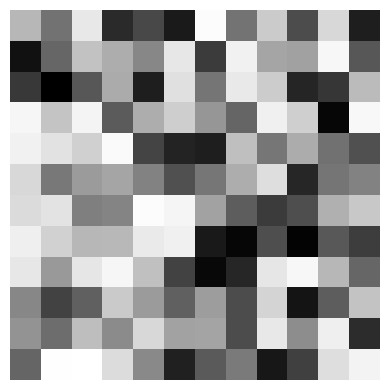

In [25]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(sample, cmap='Grays')
ax.axis("off")
plt.tight_layout()
plt.show()


### Semplice manipolazione di immagini

C'è una relazione diretta fra la rappresentazione numerica dell'immagine e la sua rappresentazione. Ne consegue che, manipolando la rappresentazione numerica, possiamo manipolare di conseguenza l'immagine:

Ad esempio introduciamo un valore fisso per i pixel nelle prime e ultime righe e colonne del'immagine precedente.

In [26]:
sample[:3, :] = 255
sample[:, :3] = 255
sample 

array([[255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255],
       [255, 255, 255, 181, 108,  77, 127, 171,  31,  76, 248,  15],
       [255, 255, 255,  11, 200, 223, 228,  93, 156, 109, 161, 191],
       [255, 255, 255, 115, 145, 191, 156, 108,  57, 221, 157, 145],
       [255, 255, 255, 143,   6,  21, 117, 179, 206, 193, 106,  83],
       [255, 255, 255,  99,  41,  31, 232, 248, 193, 251, 184, 205],
       [255, 255, 255,  20,  92, 201, 247, 221,  46,  18, 100, 170],
       [255, 255, 255,  81, 123, 176, 121, 194,  70, 236, 179,  88],
       [255, 255, 255, 137,  65, 117, 116, 194,  43, 135,  33, 217],
       [255, 255, 255,  60, 139, 226, 182, 153, 234, 203,  57,  26]])

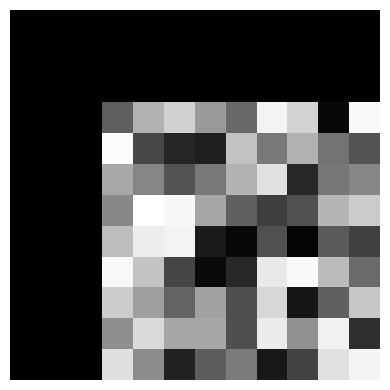

In [27]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(sample, cmap='Grays')
ax.axis("off")
plt.tight_layout()
plt.show()

### Immagini a colori

Le immagini a colori usano più matrici per rappresentare canali diversi, relativi ai diversi colori primari che comporranno l'immagine.

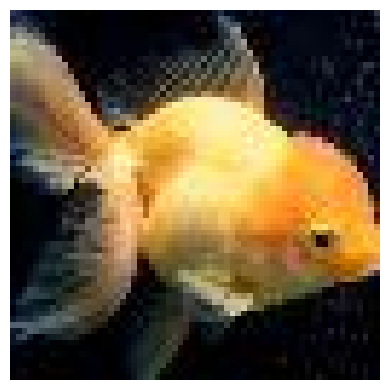

(64, 64, 3)


In [30]:
img_path = "/Users/Flint/Data/tiny-imagenet-200/train/n01443537/images/n01443537_5.JPEG"
T, R, G, B = process_image(image_path=img_path)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(T)
ax.axis("off")
plt.tight_layout()
plt.show()

print(T.shape)

In [31]:
print(T.shape, "\n")
print("Red\n", R)
print("Green\n", G)
print("Blue\n", B)

(64, 64, 3) 

Red
 [[46 31 13 ...  0  8 48]
 [22 33 49 ...  0  0 18]
 [46 71 48 ... 17  9 40]
 ...
 [ 0  2  1 ... 13  0  3]
 [ 1  7 13 ... 18  1  2]
 [ 4  6  7 ... 13  0  0]]
Green
 [[52 38 20 ...  0 12 52]
 [28 39 55 ...  0  0 22]
 [52 77 54 ... 21 13 44]
 ...
 [ 0  3  0 ... 12  0  2]
 [ 0  6 11 ... 17  0  1]
 [ 2  4  5 ... 12  0  0]]
Blue
 [[84 67 49 ... 12 24 64]
 [54 65 79 ... 12 12 34]
 [68 93 68 ... 33 25 56]
 ...
 [ 7  8  5 ... 17  5  8]
 [ 5 11 16 ... 23  8  9]
 [ 7  9  8 ... 18  7  7]]


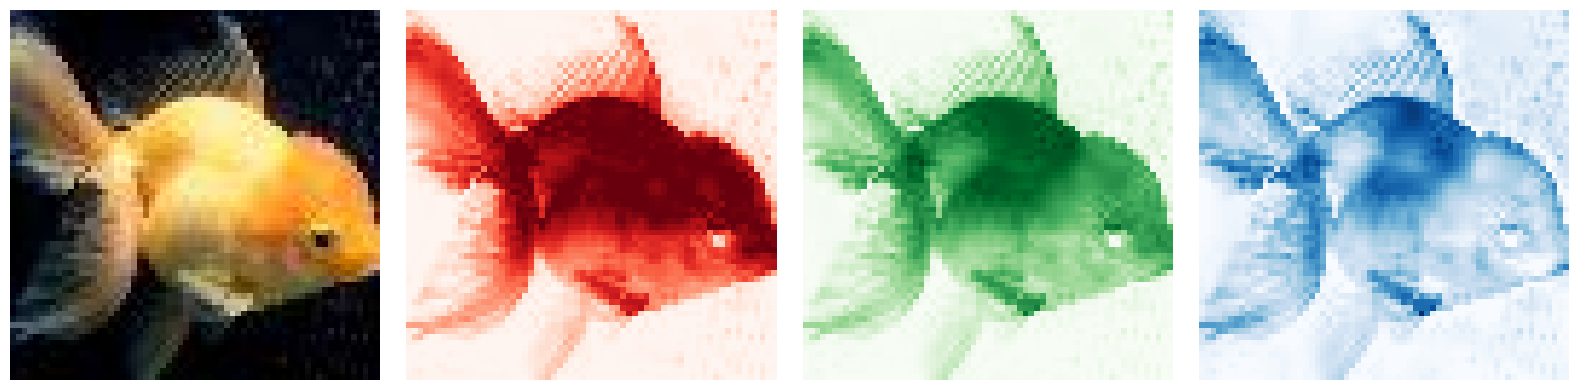

In [32]:
fig, ax = plt.subplots(figsize=(16, 4), ncols=4)
ax[0].imshow(T)
ax[0].axis("off")
ax[1].imshow(R, cmap='Reds')
ax[1].axis("off")
ax[2].imshow(G, cmap='Greens')
ax[2].axis("off")
ax[3].imshow(B, cmap='Blues')
ax[3].axis("off")
plt.tight_layout()
plt.show()


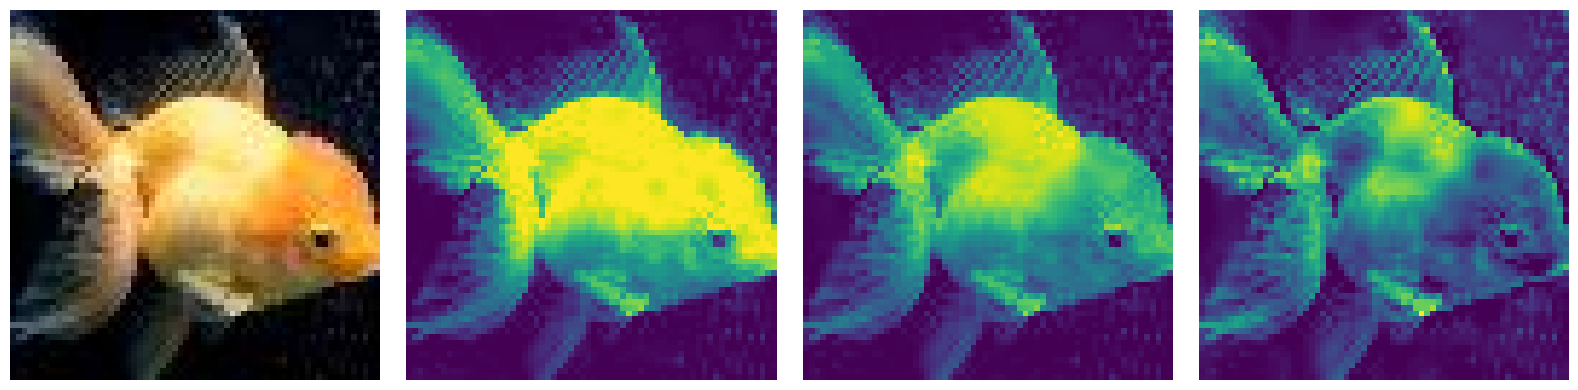

In [35]:
fig, ax = plt.subplots(figsize=(16, 4), ncols=4)
ax[0].imshow(T)
ax[0].axis("off")
ax[1].imshow(R)
ax[1].axis("off")
ax[2].imshow(G)
ax[2].axis("off")
ax[3].imshow(B)
ax[3].axis("off")
plt.tight_layout()
plt.show()


#### Operazioni sui singoli canali 
Eliminiamo il colore rosso

In [36]:
import copy

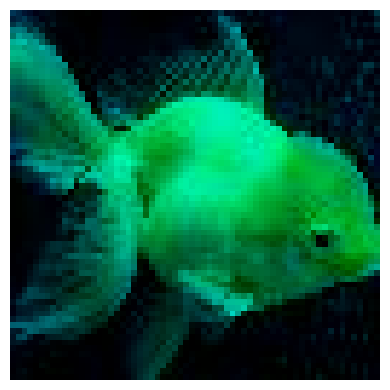

In [37]:
X = copy.deepcopy(T)

X[:,:,0] = 0

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(X)
ax.axis("off")
plt.tight_layout()
plt.show()

#### Inversione dei colori

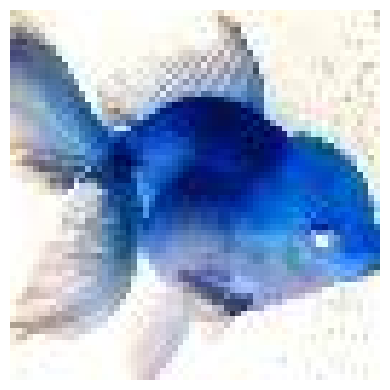

In [38]:
X = copy.deepcopy(T)
X = 255 - X 

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(X)
ax.axis("off")
plt.tight_layout()
plt.show()

#### Scala di grigi

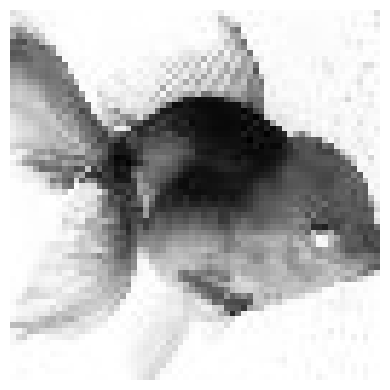

In [39]:
X = copy.deepcopy(T)
X = 0.299 * R + 0.587 * G + 0.114 * B

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(X, cmap='Grays')
ax.axis("off")
plt.tight_layout()
plt.show()

#### Soglie, luminosità e contrasto

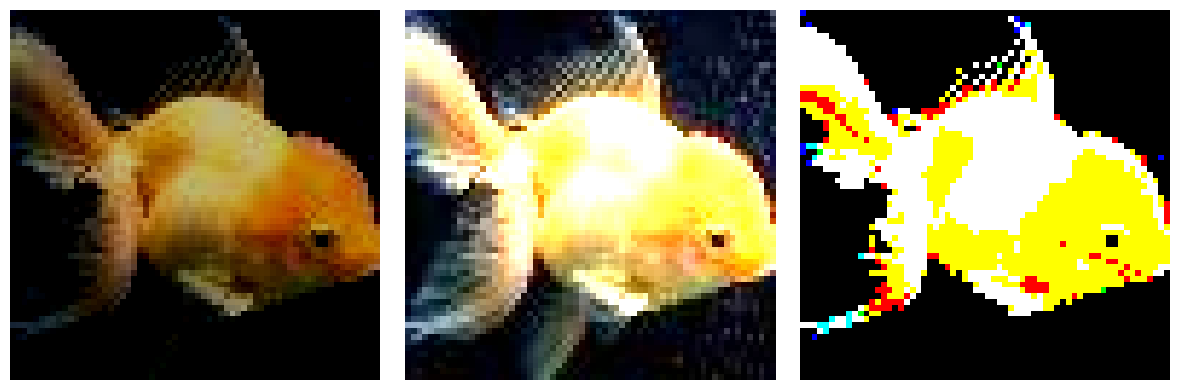

In [40]:
X1 = copy.deepcopy(T)
X2 = copy.deepcopy(T)
X3 = copy.deepcopy(T)

# luminosita
X1 = np.clip(X1 + -60, 0, 255)

# contrasto
X2 = np.clip(X2 * .007, 0, 1)

# soglie
X3 = np.where(X3 < 80, 0, 255)

fig, ax = plt.subplots(figsize=(12, 4), ncols=3)
ax[0].imshow(X1)
ax[0].axis("off")
ax[1].imshow(X2)
ax[1].axis("off")
ax[2].imshow(X3)
ax[2].axis("off")
plt.tight_layout()
plt.show()

#### Filtri e convoluzione

In [41]:
from scipy.ndimage import convolve

In [42]:
# Kernels
box_blur = np.ones((3,3)) / 9

gaussian = np.array([[1,2,1],
                     [2,4,2],
                     [1,2,1]]) / 16

sharpen = np.array([[ 0,-1, 0],
                    [-1, 5,-1],
                    [ 0,-1, 0]])

sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1,-2,-1],
                    [ 0, 0, 0],
                    [ 1, 2, 1]])

In [43]:
def apply_kernel(img, kernel):
    """Applica un kernel a ogni canale di un'immagine RGB (H x W x 3)"""
    result = np.stack([convolve(img[:,:,c].astype(float), kernel) for c in range(3)], axis=2)
    return np.clip(result, 0, 255).astype(np.uint8)

def apply_sobel(img):
    gray = (0.299*img[:,:,0] + 0.587*img[:,:,1] + 0.114*img[:,:,2])
    gx = convolve(gray, sobel_x)
    gy = convolve(gray, sobel_y)
    edges = np.clip(np.sqrt(gx**2 + gy**2), 0, 255).astype(np.uint8)
    return edges  # 2D, scala di grigi

In [44]:
img_box      = apply_kernel(T, box_blur)
img_gaussian = apply_kernel(T, gaussian)
img_sharpen  = apply_kernel(T, sharpen)
img_edges    = apply_sobel(T)

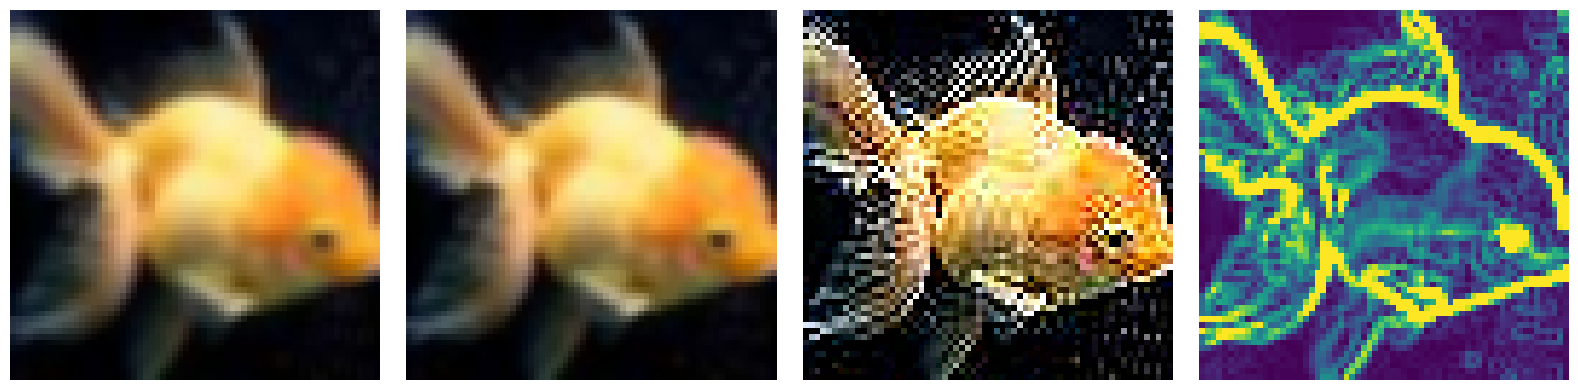

In [45]:
fig, ax = plt.subplots(figsize=(16, 4), ncols=4)
ax[0].imshow(img_box)
ax[0].axis("off")
ax[1].imshow(img_gaussian)
ax[1].axis("off")
ax[2].imshow(img_sharpen)
ax[2].axis("off")
ax[3].imshow(img_edges)
ax[3].axis("off")
plt.tight_layout()
plt.show()